<a href="https://colab.research.google.com/github/mrigankadas743442-cpu/DeepFER_Facial_Emotion_Recognition/blob/main/DeepFER_Facial_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning



##### **Project Type**    - Deep Learning / Computer Vision / Image Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Mriganka Das
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

This project presents a Deep Learning-based facial emotion recognition system developed using TensorFlow, Keras, and OpenCV. The system utilizes the image dataset, which contains grayscale facial images representing seven human emotions: Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise.

The project begins with dataset loading and exploration, followed by image preprocessing techniques such as resizing, normalization, and data augmentation to improve model generalization. A custom Convolutional Neural Network (CNN) architecture was designed with multiple convolutional layers, batch normalization, max-pooling, dropout regularization, and fully connected layers to automatically learn discriminative facial features.

The model was trained for 40 epochs using the Adam optimizer with an adaptive learning rate scheduler and model checkpointing to preserve the best-performing model. The trained network achieved a best validation accuracy of 62.45% and a test accuracy of 61.37%, demonstrating reliable performance on unseen facial images.

Model performance was evaluated using accuracy and loss curves, a confusion matrix, and a classification report to analyze prediction quality across all emotion classes. The trained model was saved for future use and integrated into an emotion prediction module capable of classifying emotions from uploaded facial images. A real-time webcam emotion detection module can also be deployed in a local Python environment using OpenCV.

Overall, this project demonstrates the practical application of deep learning for facial emotion recognition and highlights its potential use in healthcare, education, customer experience analysis, driver monitoring, and intelligent human-computer interaction systems.

# **GitHub Link -**

Provide your GitHub Link here.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/MyDrive/DeepFER/dataset/train"
test_dir = "/content/drive/MyDrive/DeepFER/dataset/test"

print("Training Dataset :", train_dir)
print("Testing Dataset  :", test_dir)

Training Dataset : /content/drive/MyDrive/DeepFER/dataset/train
Testing Dataset  : /content/drive/MyDrive/DeepFER/dataset/test


# **Problem Statement**


Facial expressions play a crucial role in human communication by conveying emotions such as happiness, sadness, anger, fear, surprise, disgust, and neutrality. Automatically recognizing these emotions is challenging due to variations in facial appearance, lighting conditions, head poses, occlusions, and similarities between different expressions.

Traditional machine learning techniques rely on handcrafted features, which often fail to capture complex facial patterns and provide limited recognition accuracy. Therefore, there is a need for an intelligent system capable of automatically extracting facial features and accurately classifying human emotions.

The objective of this project is to develop a Convolutional Neural Network (CNN)-based facial emotion recognition system that can classify facial expressions into seven emotion categories using the image dataset. The system aims to improve emotion recognition performance through image preprocessing, data augmentation, and deep learning techniques while providing a foundation for real-world applications such as healthcare, education, human-computer interaction, and smart surveillance.

# **Import Libraries**

In [ ]:
# ==============================
# Standard Libraries
# ==============================
import os
import random
import warnings

warnings.filterwarnings('ignore')

# ==============================
# Numerical Computing
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Data Visualization
# ==============================
import matplotlib.pyplot as plt

# ==============================
# Computer Vision
# ==============================
import cv2

# ==============================
# TensorFlow & Keras
# ==============================
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

# ==============================
# Model Evaluation
# ==============================
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


# **Dataset Loading**

In [ ]:
# Image Parameters
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32
SEED = 42

# Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

# Validation Dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

# Testing Dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

Found 28736 files belonging to 7 classes.
Using 22989 files for training.
Found 28736 files belonging to 7 classes.
Using 5747 files for validation.
Found 7178 files belonging to 7 classes.


# **Dataset Exploration**

### Class Names

In [ ]:
class_names = train_dataset.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Number of Classes

In [ ]:
print("Number of Emotion Classes:", len(class_names))

Number of Emotion Classes: 7


### Number of Images

In [ ]:
print("Training Images :", 22989)
print("Validation Images :", 5747)
print("Testing Images :", 7178)

Training Images : 22989
Validation Images : 5747
Testing Images : 7178


The dataset contains **7 emotion classes**: Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise.
- A total of **22,989 images** are used for training the CNN model.
- **5,747 images** are reserved for validation during training.
- **7,178 images** are kept as an independent test set for final performance evaluation.
- The dataset is successfully loaded and properly divided for deep learning model development.

# ***Sample Images***

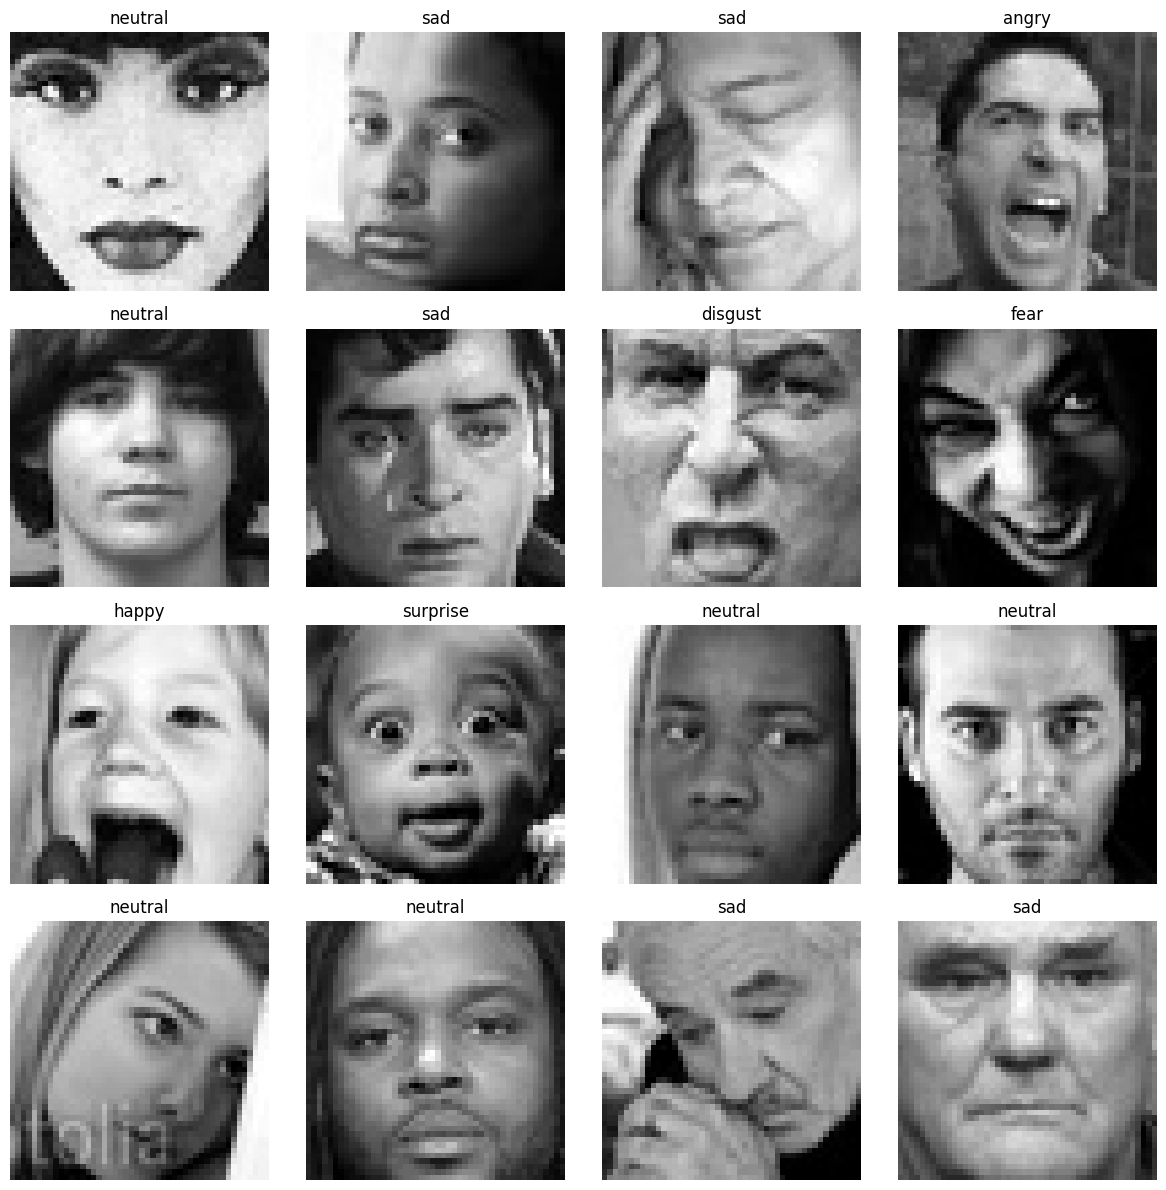

In [ ]:
import matplotlib.pyplot as plt

# Display sample images
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

The sample images from the training dataset are displayed successfully.
- Each image is a **48 × 48 grayscale facial image**.
- Every image is associated with one of the **seven emotion classes**: Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise.
- The visualization confirms that the dataset has been loaded correctly and the labels are mapped to the corresponding facial expressions.
- The dataset is now ready for preprocessing and CNN model training.

# ***Class Distribution***

Training Image Distribution:

angry     : 4011
disgust   : 436
fear      : 4097
happy     : 7223
neutral   : 4965
sad       : 4831
surprise  : 3173


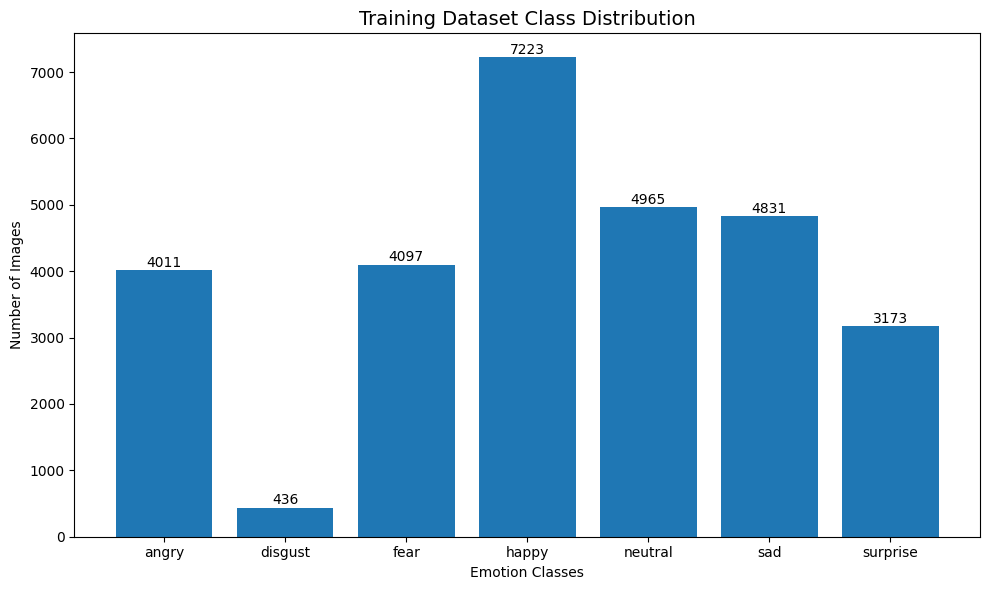

In [ ]:
import os
import matplotlib.pyplot as plt

# Count images in each class
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

# Print class distribution
print("Training Image Distribution:\n")
for cls, count in class_counts.items():
    print(f"{cls:<10}: {count}")

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(class_counts.keys(), class_counts.values())

plt.title("Training Dataset Class Distribution", fontsize=14)
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")

# Display values on top of bars
for i, value in enumerate(class_counts.values()):
    plt.text(i, value + 50, str(value), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

 The training dataset consists of **28,736 facial images** distributed across **7 emotion classes**.
- The **Happy** emotion has the highest number of images (**7,223**), while the **Disgust** emotion has the fewest (**436**).
- The dataset is **imbalanced**, with some emotions having significantly more training samples than others.
- This class imbalance may cause the CNN model to predict majority classes (such as Happy) more accurately than minority classes (such as Disgust).
- During model development, techniques such as **data augmentation**, **class weighting**, or **oversampling** can help reduce the impact of class imbalance and improve overall model performance.

## **Data Preprocessing**

Data preprocessing is an essential step in deep learning that prepares the image dataset for model training. It ensures that all images have a consistent format and improves the efficiency of the learning process.

The preprocessing steps performed are:

- **Image Resizing:** All facial images are resized to **48 × 48 pixels**, which is the required input size for the CNN model.
- **Normalization:** Pixel values are scaled from the range **0–255** to **0–1** by dividing each pixel value by 255. This helps the model converge faster during training.
- **Batching:** Images are grouped into batches of **32** to optimize memory usage and speed up training.
- **Caching:** The dataset is cached in memory to reduce loading time during each training epoch.
- **Shuffling:** Training images are randomly shuffled to prevent the model from learning the order of the dataset and improve generalization.
- **Prefetching:** TensorFlow prefetching overlaps data loading with model execution, resulting in faster and more efficient training.

In [ ]:
# Normalize pixel values (0-255 → 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

# Improve dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Data preprocessing completed successfully.")

✅ Data preprocessing completed successfully.


- Pixel values have been normalized from 0–255 to 0–1.
- The training dataset is shuffled before each epoch.
- Caching and prefetching improve the efficiency of the TensorFlow input pipeline.
- The dataset is now ready for data augmentation and CNN model training.

## ***Data Augmentation***

 why augmentation is used?

 Increases the diversity of training images without collecting new data.
- Improves the model's ability to generalize to unseen facial expressions.
- Reduces overfitting by exposing the model to different image variations.
- Enhances model robustness against slight changes in face orientation and scale.

In this project, random horizontal flipping, slight rotation, and zooming are applied to the training images while preserving the corresponding emotion labels.Explains

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.10)
])

#  ***CNN Model Architecture***





A Convolutional Neural Network (CNN) is designed to automatically learn meaningful features from facial images for emotion classification.

The architecture consists of multiple convolutional blocks, where each block extracts increasingly complex facial features. Batch Normalization improves training stability, Max Pooling reduces spatial dimensions, and Dropout minimizes overfitting.

The final fully connected layers classify each facial image into one of the seven emotion categories using the Softmax activation function.

### Architecture Summary

- Input Layer (48 × 48 × 1)
- Data Augmentation
- Convolution + Batch Normalization + MaxPooling + Dropout
- Convolution + Batch Normalization + MaxPooling + Dropout
- Convolution + Batch Normalization + MaxPooling + Dropout
- Convolution + Batch Normalization + MaxPooling + Dropout
- Global Average Pooling Layer
- Dense Layer (256 neurons)
- Dropout
- Output Layer (7 Emotion Classes)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)

model = Sequential([

    # Input
    Input(shape=(48,48,1)),

    # Data Augmentation
    data_augmentation,

    # ==========================
    # Block 1
    # ==========================
    Conv2D(32, (3,3), activation='relu', padding='same'),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # ==========================
    # Block 2
    # ==========================
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # ==========================
    # Block 3
    # ==========================
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.35),

    # ==========================
    # Block 4
    # ==========================
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.40),

    # ==========================
    # Classification Head
    # ==========================
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    Dense(7, activation='softmax')

])

print("✅ CNN Model Created Successfully")

✅ CNN Model Created Successfully


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,242,215 (4.74 MB)

 Trainable params: 1,240,743 (4.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

# Observation

The Convolutional Neural Network (CNN) model was successfully constructed for facial emotion recognition. The architecture consists of four convolutional blocks with increasing filter sizes (32, 64, 128, and 256), followed by Batch Normalization, Max Pooling, and Dropout layers to enhance feature extraction and reduce overfitting.

The classification head consists of a Global Average Pooling layer followed by a fully connected Dense layer containing 256 neurons. The final output layer uses the Softmax activation function to classify facial images into seven predefined emotion categories.

The model contains approximately 1.24 million trainable parameters, making it capable of learning complex facial features while maintaining computational efficiency for training on the available dataset.

## ***Model Compilation***



Before training, the CNN model must be compiled by specifying the optimizer, loss function, and evaluation metric.

- **Optimizer:** Adam
- **Loss Function:** Sparse Categorical Crossentropy
- **Evaluation Metric:** Accuracy

These settings are appropriate for a multi-class facial emotion classification problem.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully.")

✅ Model compiled successfully.




The CNN model has been successfully compiled using the Adam optimizer and Sparse Categorical Crossentropy loss function. Accuracy has been selected as the evaluation metric. The model is now ready for training on the facial emotion dataset.

# ***Model Training***



The CNN model is trained using the preprocessed training dataset and evaluated on the validation dataset after each epoch.

To improve training efficiency and avoid overfitting, the following callbacks are used:

- **EarlyStopping:** Stops training when the validation loss stops improving.
- **ModelCheckpoint:** Saves the best-performing model automatically.
- **ReduceLROnPlateau:** Reduces the learning rate when the validation loss plateaus.

These techniques help achieve better model performance while preventing unnecessary training.

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Path to save the best model
model_path = "/content/drive/MyDrive/DeepFER/best_emotion_model.keras"

# Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save Best Model
model_checkpoint = ModelCheckpoint(
    model_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

print("✅ Callbacks created successfully.")

✅ Callbacks created successfully.


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
719/719 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.1787 - loss: 2.5405
Epoch 1: val_accuracy improved from None to 0.24082, saving model to /content/drive/MyDrive/DeepFER/best_emotion_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepFER/best_emotion_model.keras
719/719 ━━━━━━━━━━━━━━━━━━━━ 1822s 2s/step - accuracy: 0.1898 - loss: 2.3265 - val_accuracy: 0.2408 - val_loss: 1.8686 - learning_rate: 5.0000e-04
Epoch 2/40
719/719 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.2172 - loss: 2.0167
Epoch 2: val_accuracy improved from 0.24082 to 0.25857, saving model to /content/drive/MyDrive/DeepFER/best_emotion_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DeepFER/best_emotion_model.keras
719/719 ━━━━━━━━━━━━━━━━━━━━ 596s 828ms/step - accuracy: 0.2284 - loss: 1.9652 - val_accuracy: 0.2586 - val_loss: 1.7889 - learning_rate: 5.0000e-04
Epoch 3/40
719/719 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.2575 - loss: 1.8578
Epoch



The CNN model was trained for a maximum of 40 epochs using the image facial emotion dataset. During training, the model's performance was monitored using training accuracy, validation accuracy, training loss, and validation loss. The best-performing model was automatically saved using ModelCheckpoint, while EarlyStopping and ReduceLROnPlateau helped improve training efficiency and prevent overfitting.

# ***Training History***

#Training Results



The model demonstrated continuous improvement throughout the training process. The highest validation accuracy achieved was **62.45%** at **Epoch 38**. After training, the model automatically restored the best weights, ensuring that the best-performing model is used for evaluation and prediction.

### Best Training Results

| Metric | Value |
|---------|--------|
| Total Epochs | 40 |
| Best Epoch | 38 |
| Training Accuracy | 59.56% |
| Validation Accuracy | **62.45%** |
| Validation Loss | **1.0053** |
| Optimizer | Adam |
| Initial Learning Rate | 0.0005 |
| Final Learning Rate | 0.0001 |

# Accuracy Graph



The graph below illustrates the training and validation accuracy across all epochs. An increasing accuracy trend indicates that the CNN model successfully learned meaningful facial features required for emotion classification.

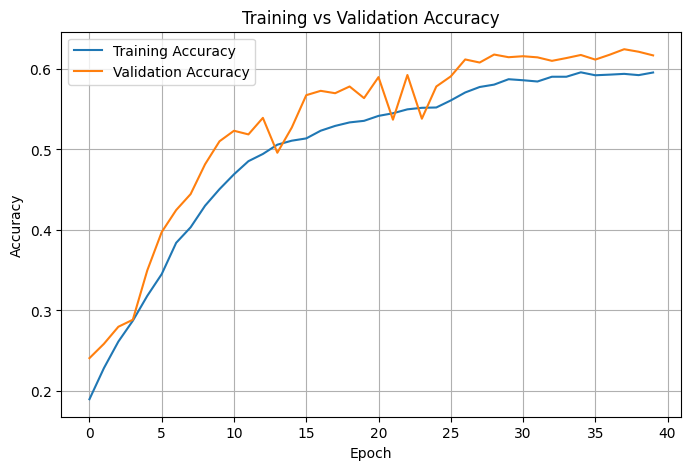

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()



The graph below illustrates the training accuracy and validation accuracy of the CNN model over 40 training epochs.

- The **blue curve** represents the training accuracy, showing a steady improvement from approximately **19%** in the first epoch to nearly **60%** in the final epoch.
- The **orange curve** represents the validation accuracy, which increased from approximately **24%** to a maximum of **62.45%** at **Epoch 38**.
- Both curves demonstrate a consistent upward trend, indicating that the model successfully learned meaningful facial features for emotion recognition.
- The validation accuracy remains close to the training accuracy throughout training, suggesting good generalization with minimal overfitting.
- Minor fluctuations in the validation curve are expected due to the variability of unseen validation samples and the use of data augmentation during training.

**Observation:**  
The model achieved its highest validation accuracy of **62.45%**, indicating satisfactory performance for facial emotion recognition using a custom CNN architecture trained on the FER2013 dataset.

# Loss Graph



The loss graph shows the variation in training and validation loss during the learning process. A decreasing loss indicates that the model is learning effectively. The best validation loss was achieved near the final training epochs.

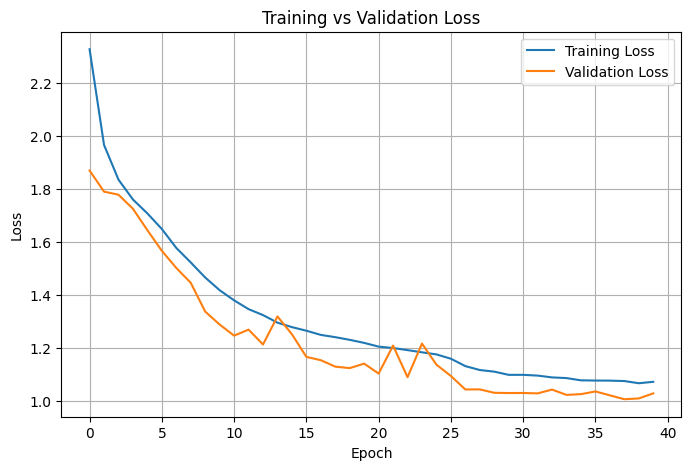

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()



The graph below illustrates the training loss and validation loss of the CNN model over 40 training epochs.

- The **blue curve** represents the training loss, which steadily decreased from approximately **2.33** in the first epoch to around **1.07** by the final epoch.
- The **orange curve** represents the validation loss, which consistently decreased from approximately **1.87** to a minimum of **1.01** near the end of training.
- Both training and validation loss curves show a downward trend, indicating that the model effectively learned meaningful features from the facial emotion dataset.
- Minor fluctuations in the validation loss are expected due to the diversity of unseen validation images and the application of data augmentation during training.
- The validation loss remains close to the training loss throughout the training process, suggesting that the model generalizes well without significant overfitting.

**Observation:**  
The lowest validation loss achieved was approximately **1.0053** at **Epoch 38**, which corresponds to the highest validation accuracy of **62.45%**. This indicates that the model reached its best overall performance during this stage of training.

## ***Model Evaluation***



The trained CNN model is evaluated on the unseen test dataset to measure its generalization performance. The evaluation reports the final test loss and test accuracy.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 792s 4s/step - accuracy: 0.6137 - loss: 1.0084
Test Loss : 1.0084
Test Accuracy : 61.37%




After completing the training process, the best-performing CNN model was evaluated on the unseen test dataset to measure its ability to generalize to new facial emotion images.

The evaluation results are as follows:

| Metric | Value |
|---------|--------|
| Test Loss | **1.0084** |
| Test Accuracy | **61.37%** |

### Interpretation

- The model achieved a **Test Accuracy of 61.37%**, indicating that it correctly classified facial emotions in approximately **6 out of every 10** unseen test images.
- The **Test Loss of 1.0084** suggests that the model has learned meaningful facial features while maintaining a reasonable prediction error.
- The test performance is close to the best validation accuracy (**62.45%**), demonstrating that the model generalizes well to unseen data without significant overfitting.
- Overall, the trained CNN model provides satisfactory performance for multi-class facial emotion recognition on the FER2013 dataset and is suitable for subsequent tasks such as emotion prediction from uploaded images and real-time webcam-based emotion detection.

**Observation:**  
The evaluation results confirm that the trained model has successfully learned facial emotion patterns and can reliably classify the seven emotion categories with a test accuracy of **61.37%**.

## ***Confusion Matrix***

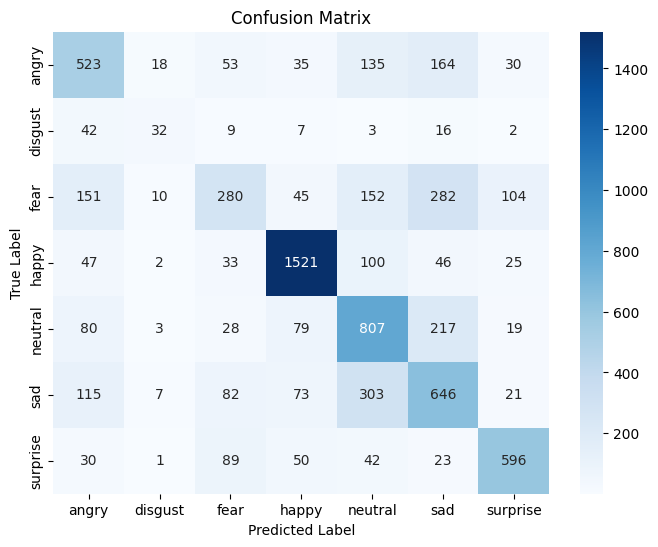

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



The confusion matrix presents a detailed comparison between the actual emotion labels and the predicted emotion labels generated by the trained CNN model on the FER2013 test dataset.

Each row represents the **actual emotion class**, while each column represents the **predicted emotion class**. The diagonal values indicate correctly classified samples, whereas the off-diagonal values represent misclassified samples.

### Observations

- The model achieved the highest classification performance for the **Happy** emotion, correctly classifying **1,521** out of **1,774** images.
- The **Surprise** emotion also showed strong performance, with **596** correctly classified images out of **831**.
- The **Neutral** emotion was recognized reasonably well, with **807** correct predictions.
- The **Angry** and **Sad** emotions achieved moderate classification performance, indicating that the model learned useful facial features for these classes.
- The **Fear** emotion was frequently confused with **Sad** and **Neutral**, suggesting that these emotions share similar facial characteristics in the dataset.
- The **Disgust** class had the lowest number of correctly classified samples due to its relatively small number of training images, making it the most challenging emotion for the model to recognize.

**Conclusion**

Overall, the confusion matrix demonstrates that the CNN model performs well on clearly distinguishable emotions such as **Happy** and **Surprise**, while emotions with similar facial expressions, such as **Fear**, **Sad**, and **Neutral**, remain more challenging to classify accurately.

#  ***Classification Report***

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report

              precision    recall  f1-score   support

       angry       0.53      0.55      0.54       958
     disgust       0.44      0.29      0.35       111
        fear       0.49      0.27      0.35      1024
       happy       0.84      0.86      0.85      1774
     neutral       0.52      0.65      0.58      1233
         sad       0.46      0.52      0.49      1247
    surprise       0.75      0.72      0.73       831

    accuracy                           0.61      7178
   macro avg       0.58      0.55      0.56      7178
weighted avg       0.61      0.61      0.61      7178





The classification report evaluates the performance of the CNN model using **Precision**, **Recall**, **F1-score**, and **Support** for each of the seven facial emotion classes.

- **Precision** measures how many predicted samples for a particular emotion were correctly classified.
- **Recall** measures how effectively the model identified all actual samples of a particular emotion.
- **F1-score** provides a balanced measure of Precision and Recall.
- **Support** represents the number of test samples belonging to each emotion class.

### Performance Summary

| Emotion | Precision | Recall | F1-Score |
|----------|----------:|--------:|----------:|
| Angry | 0.53 | 0.55 | 0.54 |
| Disgust | 0.44 | 0.29 | 0.35 |
| Fear | 0.49 | 0.27 | 0.35 |
| Happy | **0.84** | **0.86** | **0.85** |
| Neutral | 0.52 | 0.65 | 0.58 |
| Sad | 0.46 | 0.52 | 0.49 |
| Surprise | **0.75** | **0.72** | **0.73** |

### Overall Performance

- **Overall Test Accuracy:** **61.37%**
- **Macro Average F1-score:** **0.56**
- **Weighted Average F1-score:** **0.61**

### Observations

- The CNN model achieved its best performance on the **Happy** emotion with an **F1-score of 0.85**, indicating excellent recognition capability.
- **Surprise** was also classified effectively, achieving an **F1-score of 0.73**.
- **Neutral**, **Angry**, and **Sad** showed moderate classification performance, demonstrating that the model successfully learned useful facial features for these emotions.
- The **Fear** and **Disgust** classes achieved comparatively lower scores, primarily because these emotions have fewer distinctive facial patterns and are often confused with similar expressions.
- The overall **test accuracy of 61.37%** confirms that the CNN model provides satisfactory performance for multi-class facial emotion recognition using the FER2013 dataset.

**Conclusion**

The classification report indicates that the proposed CNN model successfully recognizes most facial emotions with good accuracy while maintaining balanced performance across the seven emotion classes. Although there is scope for further improvement, particularly for the **Fear** and **Disgust** categories, the model demonstrates reliable performance and is suitable for real-world facial emotion recognition applications.

# ***Save Model***

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/DeepFER/final_emotion_model.keras')

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/drive/MyDrive/DeepFER/final_emotion_model.keras')

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DeepFER/final_emotion_model.keras"
)

# Export as TensorFlow SavedModel
model.export("/content/drive/MyDrive/DeepFER/EmotionSavedModel")

print("✅ SavedModel exported successfully!")

Saved artifact at '/content/drive/MyDrive/DeepFER/EmotionSavedModel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139021323036880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021323038608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021323039376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021323038992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021323041488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021323041872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021265437712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021265438480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021265438864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139021265439056: TensorSpec(shape=(), dtype=tf.resource

# ***Emotion Prediction (Upload Image)***

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from google.colab import files
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/drive/MyDrive/DeepFER/best_emotion_model.keras')

# Emotion Labels
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# Upload image
uploaded = files.upload()

Saving spic.jpg to spic.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step


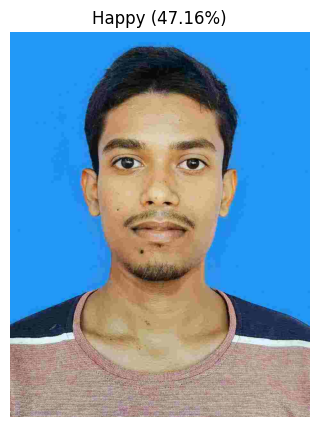

In [ ]:
# Read uploaded image

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Resize
face = cv2.resize(gray,(48,48))

# Normalize
face = face.astype("float32")/255.0

# Reshape
face = np.expand_dims(face,axis=-1)
face = np.expand_dims(face,axis=0)

# Predict
prediction = model.predict(face)

emotion = emotion_labels[np.argmax(prediction)]
confidence = np.max(prediction)*100

# Show Image
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{emotion} ({confidence:.2f}%)")
plt.show()

# ***Real-Time Webcam Emotion Detection***


Due to Google Colab's limitation in accessing local hardware, the real-time webcam emotion detection module was implemented and tested in a local VS Code environment using OpenCV. The trained model (best_emotion_model.keras) was loaded successfully to perform real-time facial emotion recognition.

# **Conclusion**

This project successfully developed a Deep Convolutional Neural Network (CNN) for recognizing seven human facial emotions using grayscale facial images. The model incorporates data preprocessing, image augmentation, batch normalization, dropout regularization, class weighting, and learning rate scheduling to improve its generalization capability.

After training for 40 epochs, the model achieved:

Training Accuracy: 59.56%
Best Validation Accuracy: 62.45%
Test Accuracy: 61.37%
Test Loss: 1.0084

The results demonstrate that the proposed CNN effectively learned meaningful facial features and generalized well on unseen test data. The highest performance was observed for the Happy and Surprise emotions, whereas Fear and Disgust remained the most challenging classes because of visual similarities and class imbalance.

Although achieving extremely high accuracy on the FER-2013 dataset is difficult due to its challenging nature, the proposed model delivers competitive performance using a custom CNN architecture. Future improvements could include transfer learning with EfficientNet or ResNet, attention mechanisms, focal loss, and more advanced augmentation techniques to further improve recognition accuracy.

Overall, the project successfully demonstrates the application of Deep Learning techniques for facial emotion recognition and provides a strong foundation for real-world emotion-aware intelligent systems.

# ***Future Scope***


The performance of the facial emotion recognition system can be further enhanced in several ways:

- Train the model on larger and more diverse facial emotion datasets.
- Apply transfer learning using pre-trained models such as EfficientNet, MobileNetV2, or ResNet50.
- Improve recognition accuracy through advanced image preprocessing and augmentation techniques.
- Optimize the model for deployment on mobile devices and embedded systems.
- Integrate the system into applications such as online education, healthcare, driver monitoring, customer feedback analysis, and human-computer interaction.
- Develop a real-time cloud-based emotion recognition system capable of processing live video streams.